# Project 03 — Does Global Liquidity Lead Bitcoin?

## 1.Data Collection.
##### - Fed / ECB / BOJ balance sheets, RRP, TGA, M2, real yields (FRED)
##### - BTC, DXY, VIX, Nasdaq prices (Yahoo Finance)

In [28]:
pip install python-dotenv


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from dotenv import load_dotenv
import os
load_dotenv() 
FRED_API_KEY = os.getenv("API_KEY")

Shape: (4638, 8)
Shape: (4560, 4)


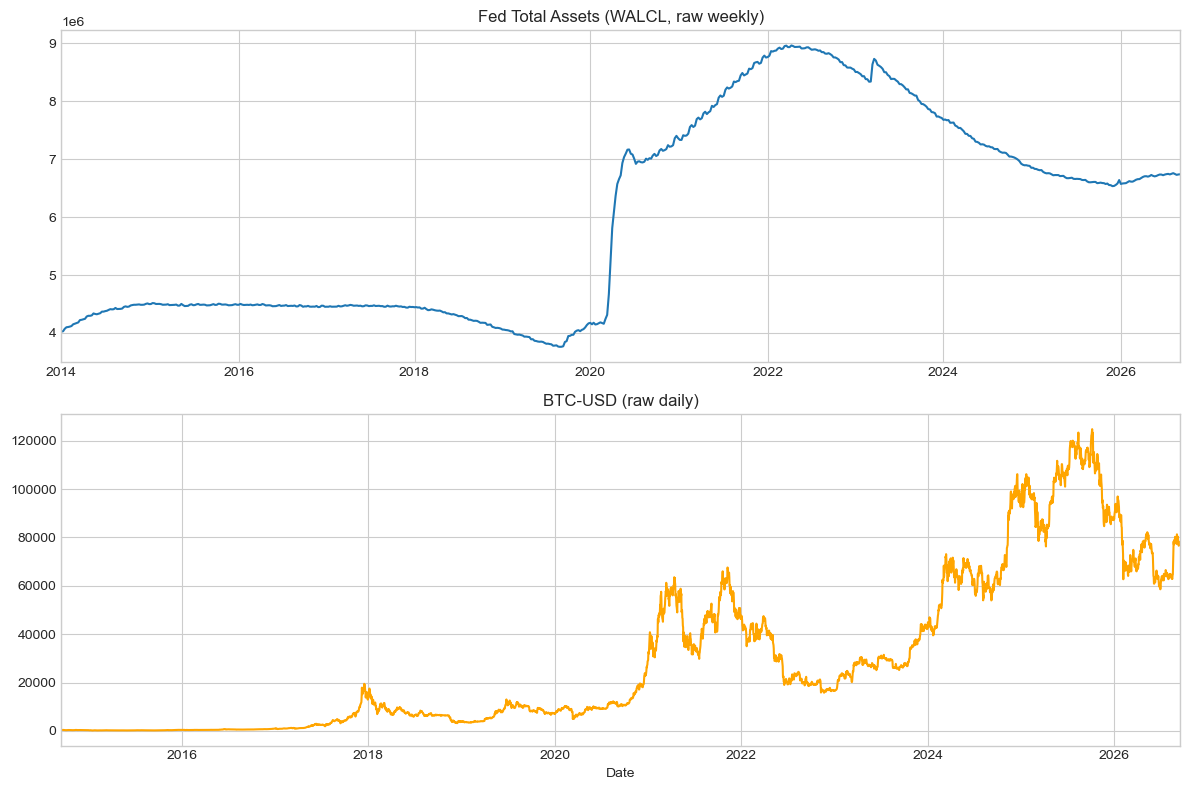

Fred weekly shape: (664, 8)
Yahoo weekly shape: (664, 4)


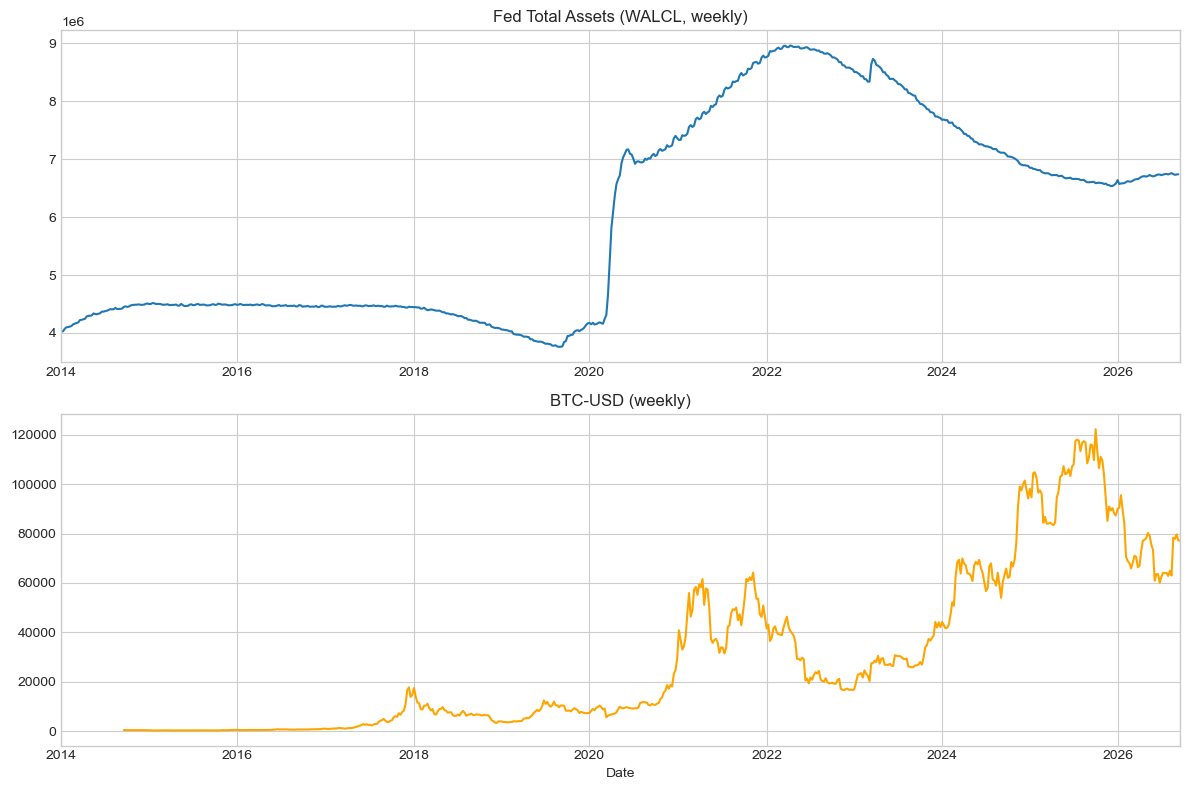

Merged panel shape: (627, 12)


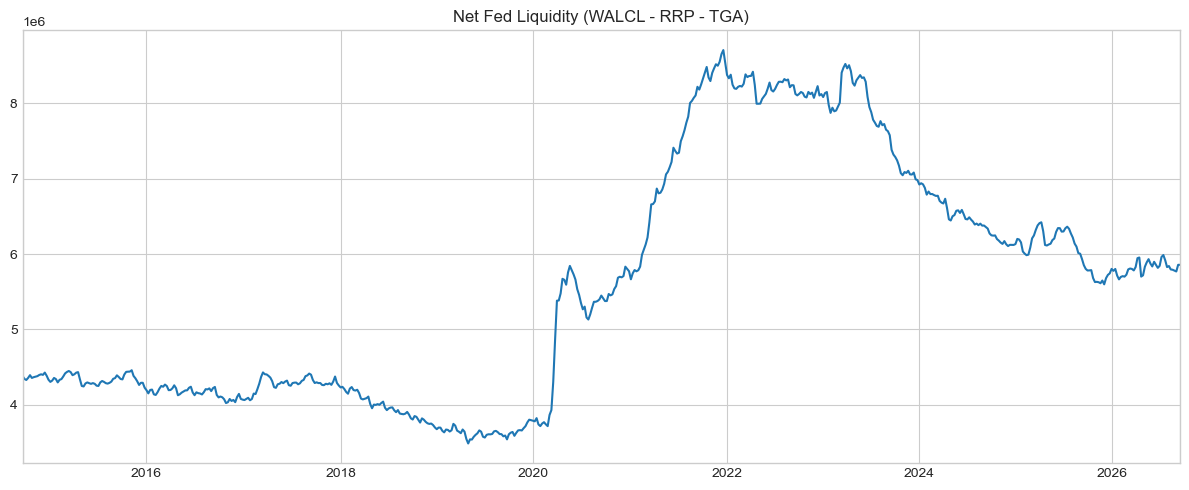

Saved to ../data/processed/weekly_panel_levels.csv
Final shape: (627, 13)


,fed_assets,reverse_repo,tga,ecb_assets,boj_assets,m2_us,real_yield_10y,fed_funds_rate,btc,dxy,vix,nasdaq,net_fed_liquidity
count,6.270000e+02,627.000000,6.270000e+02,6.270000e+02,6.270000e+02,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,627.000000,6.270000e+02
mean,6.092502e+06,448.255450,5.270032e+05,5.553101e+06,6.052384e+06,17592.751675,0.711244,2.056794,29569.690798,98.112719,18.059282,11501.299873,5.565051e+06
std,1.743361e+06,713.051556,3.935564e+05,1.917555e+06,1.377346e+06,3960.301984,0.984509,1.899053,32607.761685,4.973131,6.753644,5937.903917,1.581892e+06
min,3.759946e+06,0.000000,2.979500e+04,1.988153e+06,2.770994e+06,11520.700000,-1.160000,0.050000,208.097000,84.800003,9.140000,4258.439941,3.489193e+06
25%,4.461114e+06,5.083000,2.358940e+05,4.313750e+06,5.134438e+06,13743.000000,0.145000,0.130000,3634.109985,94.805000,13.475000,6431.125000,4.209654e+06
50%,6.605962e+06,99.961000,3.789470e+05,6.070545e+06,6.446620e+06,18605.000000,0.560000,1.560000,13546.522461,97.639999,16.370001,10705.410156,5.574580e+06
75%,7.562666e+06,437.418500,7.630715e+05,6.964478e+06,7.253573e+06,21336.700000,1.695000,3.830000,49952.955078,101.235001,20.945001,15002.159668,6.676190e+06
max,8.965487e+06,2553.716000,1.816687e+06,8.835987e+06,7.648115e+06,23218.000000,2.600000,5.330000,122266.531250,113.309998,66.040001,26972.619141,8.703963e+06


In [30]:
## Download FRED series (Fed/ECB/BOJ balance sheets, rates, M2)
fred_data = {}
for name, code in FRED_SERIES.items():
    print(f"Downloading {name} ({code}) ...")
    fred_data[name] = fred.get_series(code)
    time.sleep(0.3)  # be polite to the API

fred_df = pd.DataFrame(fred_data)
fred_df.index = pd.to_datetime(fred_df.index)
fred_df = fred_df.sort_index()
fred_df = fred_df.loc[fred_df.index >= START_DATE]

fred_df.to_csv(f"{RAW_DIR}/fred_raw.csv")
print("Shape:", fred_df.shape)
fred_df.tail()


## Download Yahoo Finance series (BTC, DXY, VIX, Nasdaq)
yahoo_data = {}
for name, ticker in YAHOO_TICKERS.items():
    print(f"Downloading {name} ({ticker}) ...")
    raw = yf.download(ticker, start=START_DATE, progress=False)
    col = "Adj Close" if "Adj Close" in raw.columns else "Close"
    # handle MultiIndex columns from newer yfinance versions
    if isinstance(raw.columns, pd.MultiIndex):
        yahoo_data[name] = raw[col].iloc[:, 0]
    else:
        yahoo_data[name] = raw[col]

yahoo_df = pd.DataFrame(yahoo_data)
yahoo_df.index = pd.to_datetime(yahoo_df.index)
yahoo_df = yahoo_df.sort_index()

yahoo_df.to_csv(f"{RAW_DIR}/yahoo_raw.csv")
print("Shape:", yahoo_df.shape)
yahoo_df.tail()


## Raw sanity check (before any resampling)
# Note: WALCL (Fed total assets) is published weekly (every Wednesday), so raw fred_df has large gaps between observations. I drop NaNs 
# explicitly here just for the visual check — this is NOT the data I will actually use for modeling.

fig, axes = plt.subplots(2, 1, figsize=(12, 8))


fred_df["fed_assets"].dropna().plot(ax=axes[0], title="Fed Total Assets (WALCL, raw weekly)")
yahoo_df["btc"].dropna().plot(ax=axes[1], title="BTC-USD (raw daily)", color="orange")
plt.tight_layout()
plt.savefig("../reports/figures/01_raw_data_check.png", dpi=150)
plt.show()

## Resample everything to weekly (Friday) frequency
# Fed/ECB/BOJ data is published weekly (Wednesdays), while BTC/DXY/VIX/Nasdaq are daily. 
# To align both sets on a single common grid, we first forward-fill each series onto a continuous daily index, then take the Friday value.
# This removes weekend/holiday gaps and guarantees no missing weeks in either dataset before merging — which is 
# exactly what was missing before and caused the "empty" Fed Total Assets chart downstream.
def resample_to_weekly(df, agg="last"):
    """Resample any dataframe to weekly (Friday) frequency, ffill first."""
    daily = df.sort_index().resample("D").ffill()
    if agg == "last":
        return daily.resample("W-FRI").last()
    return daily.resample("W-FRI").mean()

fred_weekly = resample_to_weekly(fred_df)
yahoo_weekly = resample_to_weekly(yahoo_df)

print("Fred weekly shape:", fred_weekly.shape)
print("Yahoo weekly shape:", yahoo_weekly.shape)

## Sanity check plot (weekly-resampled, gap-free data)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fred_weekly["fed_assets"].plot(ax=axes[0], title="Fed Total Assets (WALCL, weekly)")
yahoo_weekly["btc"].plot(ax=axes[1], title="BTC-USD (weekly)", color="orange")
plt.tight_layout()
plt.savefig("../reports/figures/01_weekly_data_check.png", dpi=150)
plt.show()


## Merge FRED + Yahoo into a single weekly panel
# This step was missing before — `panel` was referenced later without ever
# being created, which is the actual root cause of downstream issues.
# We use an outer join on the weekly Friday index, then trim to the range
# where BOTH datasets have data (BTC only starts trading in Sep 2014,
# so early rows will be all-NaN for btc/dxy/vix/nasdaq — we drop those).

panel = fred_weekly.join(yahoo_weekly, how="outer")
# forward-fill any small residual gaps (e.g. a holiday shifting a Friday value)
panel = panel.ffill()
# drop leading rows where BTC (or other yahoo series) is not yet available
panel = panel.dropna(subset=["btc"])
print("Merged panel shape:", panel.shape)
panel.tail()


## Construct Net Fed Liquidity
# Net Liquidity = Fed Total Assets − Reverse Repo − Treasury General Account
# Rationale: RRP and TGA represent liquidity parked outside the banking
# system / markets (money market funds parking cash at the Fed, or cash
# sitting in the Treasury's checking account), so subtracting them from
# gross Fed assets gives a cleaner proxy of liquidity actually available to financial markets.
panel["net_fed_liquidity"] = (
    panel["fed_assets"] - panel["reverse_repo"] - panel["tga"]
)

fig, ax = plt.subplots(figsize=(12, 5))
panel["net_fed_liquidity"].plot(ax=ax, title="Net Fed Liquidity (WALCL - RRP - TGA)")
plt.tight_layout()
plt.savefig("../reports/figures/01_net_fed_liquidity.png", dpi=150)
plt.show()

## Save processed weekly panel (levels, not yet stationary-transformed)
# Stationarity transforms (log-diff, pct_change) will be handled in the next notebook (02_stationarity_transforms.ipynb) — 
# we keep raw levels here so the processed file stays a faithful, re-usable snapshot of 
# the merged dataset.
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

panel.to_csv(f"{PROCESSED_DIR}/weekly_panel_levels.csv")
print(f"Saved to {PROCESSED_DIR}/weekly_panel_levels.csv")
print("Final shape:", panel.shape)
panel.describe()

## Final data quality check before closing this notebook. 

In [31]:
# Quick explicit check for missing values and date range coverage.This is the last sanity gate before moving to 02_stationarity_transforms.ipynb.

print("Date range:", panel.index.min(), "to", panel.index.max())
print("\nMissing values per column:")
print(panel.isna().sum())

print("Total weeks:", len(panel))

Date range: 2014-09-19 00:00:00 to 2026-09-18 00:00:00

Missing values per column:
fed_assets           0
reverse_repo         0
tga                  0
ecb_assets           0
boj_assets           0
m2_us                0
real_yield_10y       0
fed_funds_rate       0
btc                  0
dxy                  0
vix                  0
nasdaq               0
net_fed_liquidity    0
dtype: int64
Total weeks: 627


### Сonclusions
####  This notebook collected and aligned two structurally different data sources — weekly-published central bank balance sheet data (FRED) #### and daily market prices (Yahoo Finance) — onto a single, gap-free weekly (Friday) panel.
#### Key steps:
#### 1.Downloaded 8 FRED series (Fed/ECB/BOJ balance sheets, RRP, TGA, M2, real yields, Fed Funds rate) and 4 Yahoo series (BTC, DXY, VIX, Nasdaq).
#### 2. Resampled both sources to a common weekly-Friday grid via forward-fill,resolving the frequency mismatch between weekly FRED publications and daily market data.
#### 3. Merged both sources into a single panel, trimmed to the period where BTC price data actually exists (post Sep-2014).
#### 4. Constructed `net_fed_liquidity` (WALCL − RRP − TGA) as a cleaner proxy for liquidity actually available to markets, rather than relying on the raw Fed balance sheet alone.
#### 5. Verified data quality (no unexpected gaps, plausible ranges) and saved the result as `weekly_panel_levels.csv` — raw levels, not yet stationarity-transformed.

In [32]:
print(f"""
Summary: collected and merged {panel.shape[1]} variables into a weekly panel
of {panel.shape[0]} observations, from {panel.index.min().date()} to {panel.index.max().date()}.
Saved to {PROCESSED_DIR}/weekly_panel_levels.csv — ready for stationarity transforms.`02_stationarity_transforms.ipynb` 
""")


Summary: collected and merged 13 variables into a weekly panel
of 627 observations, from 2014-09-19 to 2026-09-18.
Saved to ../data/processed/weekly_panel_levels.csv — ready for stationarity transforms.`02_stationarity_transforms.ipynb` 

